In [28]:
import pandas as pd 
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [30]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [31]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isnull().sum()

np.int64(11)

In [32]:
df.loc[df['tenure']==0 , 'TotalCharges'] = 0

In [33]:
df['TotalCharges'].isnull().sum()

# Handeling the missing values by filling with 0 if tenure is 0

np.int64(0)

In [34]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})
df['gender'] = df['gender'].map({'Male':1, 'Female':0})

In [35]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,1,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [36]:
df.drop(columns=['customerID'], inplace=True)

In [37]:
df = pd.get_dummies(df, drop_first=True).head()
df.head()


,gender,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,29.85,29.85,0,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,1,0,34,56.95,1889.50,0,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,1,0,2,53.85,108.15,1,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,1,0,45,42.30,1840.75,0,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,0,2,70.70,151.65,1,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


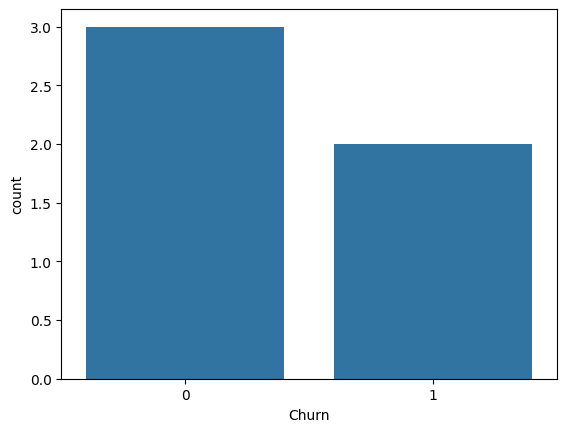

In [38]:
sns.countplot(x='Churn', data=df)
plt.show()


In [27]:
df.head()

,gender,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,29.85,29.85,0,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,1,0,34,56.95,1889.50,0,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,1,0,2,53.85,108.15,1,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,1,0,45,42.30,1840.75,0,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,0,0,2,70.70,151.65,1,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False


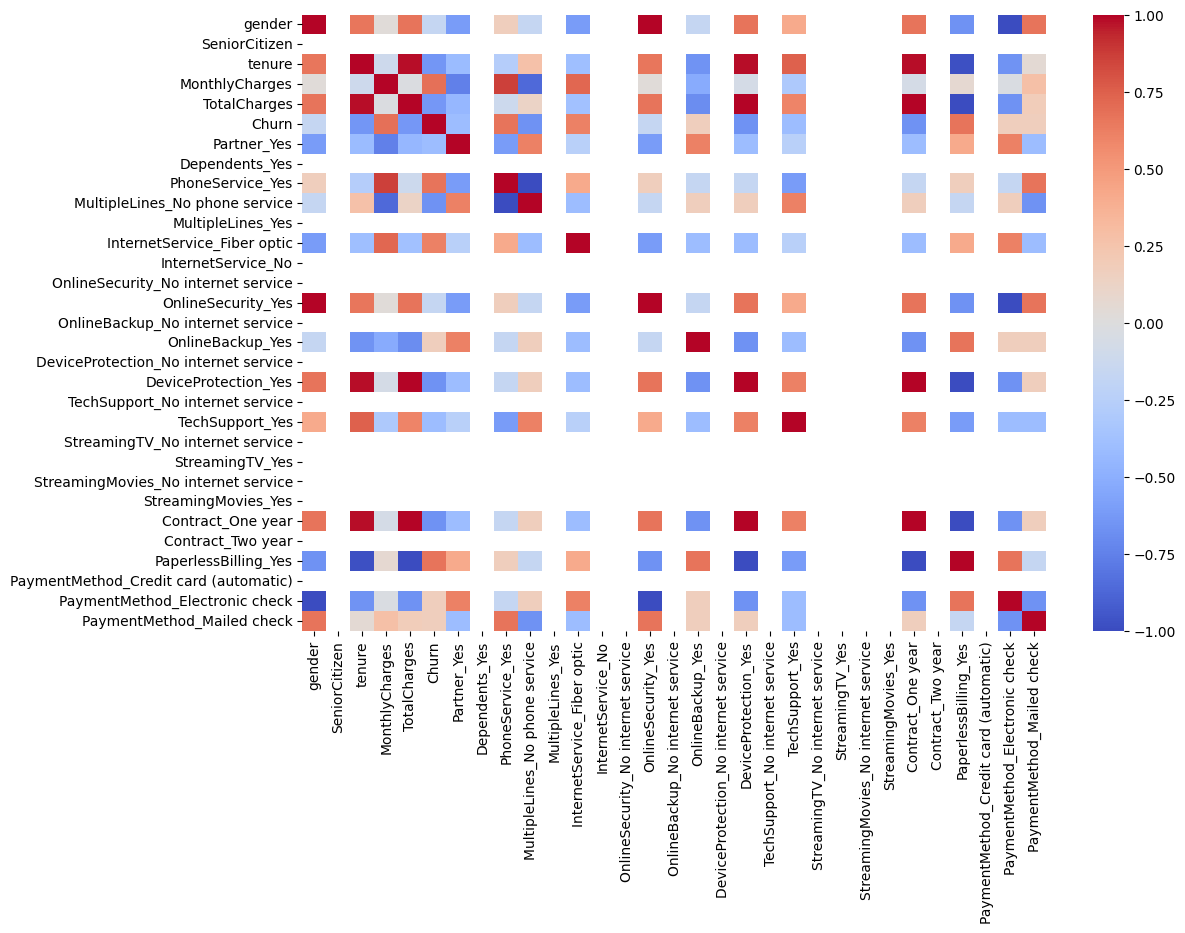

In [41]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

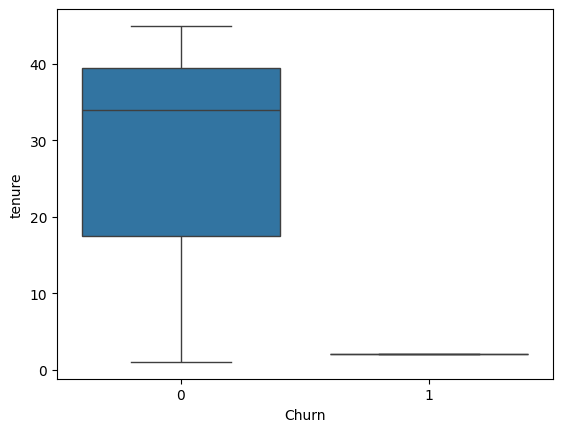

In [42]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.show()


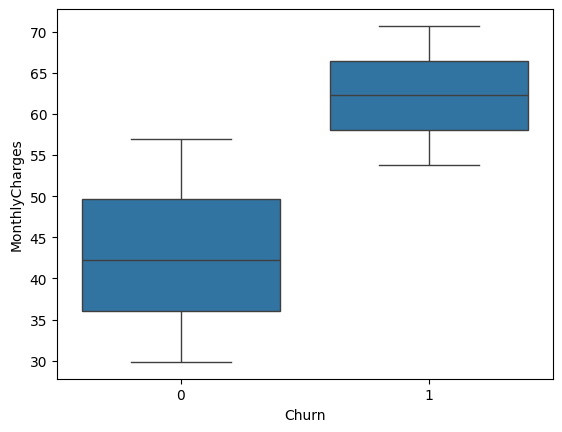

In [43]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()


In [46]:
df['AvgCharges'] = df['TotalCharges'] / (df['tenure'] + 1)
df.head()


,gender,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,AvgCharges
0,0,0,1,29.85,29.85,0,True,False,False,True,...,False,False,False,False,False,True,False,True,False,14.925000
1,1,0,34,56.95,1889.50,0,False,False,True,False,...,False,False,False,True,False,False,False,False,True,53.985714
2,1,0,2,53.85,108.15,1,False,False,True,False,...,False,False,False,False,False,True,False,False,True,36.050000
3,1,0,45,42.30,1840.75,0,False,False,False,True,...,False,False,False,True,False,False,False,False,False,40.016304
4,0,0,2,70.70,151.65,1,False,False,True,False,...,False,False,False,False,False,True,False,True,False,50.550000


In [52]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=32)

model = LogisticRegression(max_iter=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 1.0


In [51]:
print("confusion matrix:", confusion_matrix(y_test, y_pred))

confusion matrix: [[1]]


/Users/rahaman/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
